# WomenLife: Female Life Expectancy Prediction

## Mission:
The goal of this project is to build and deploy a regression model capable of accurately predicting life expectancy, with a focus on factors affecting women's longevity across countries.

This model is part of a broader mission to understand how socio-economic and health indicators influence women's quality of life globally. By identifying key drivers such as education, disease prevalence, and economic conditions, this system can support policymakers and organizations in making data-driven decisions to improve women's health outcomes.

In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Data Loading and Cleaning

In [24]:
def load_and_clean_data(file_path='Life Expectancy Data.csv'):
    """
    Loads the WHO Life Expectancy dataset, cleans it, and prepares for analysis.
    Focus on features that impact women's health.
    """
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. ")
        return ImportError()

    df = pd.read_csv(file_path)
    print("Dataset loaded successfully")

    # Display initial shape
    print(f"Initial dataset shape: {df.shape}")

    # Drop rows with missing values (simple approach)
    initial_rows = len(df)
    df = df.dropna()
    print(f"Dropped {initial_rows - len(df)} rows with missing values")

    # Drop non-numeric columns that won't be useful for prediction
    cols_to_drop = []
    if "Country" in df.columns:
        cols_to_drop.append("Country")
    if "Year" in df.columns:
        # Keep Year for potential time analysis, but we'll handle separately
        pass

    df = df.drop(columns=cols_to_drop, errors='ignore')

    return df


# Load the dataset
print("Loading WHO Life Expectancy Dataset...")
df = load_and_clean_data('Life Expectancy Data.csv')

print(f"\nDataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10 columns
print(f"Target variable: Life expectancy (range: {df['Life expectancy '].min():.1f} to {df['Life expectancy '].max():.1f} years)")

Loading WHO Life Expectancy Dataset...
Dataset loaded successfully
Initial dataset shape: (2938, 22)
Dropped 1289 rows with missing values

Dataset Overview:
Shape: (1649, 21)
Columns: ['Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ']...
Target variable: Life expectancy (range: 44.0 to 89.0 years)


## Exploratory Data Analysis and Visualisation


Top 5 Positive Correlations with Life Expectancy:
Life expectancy                    1.000000
Schooling                          0.727630
Income composition of resources    0.721083
 BMI                               0.542042
GDP                                0.441322
Name: Life expectancy , dtype: float64

Top 5 Negative Correlations with Life Expectancy:
under-five deaths       -0.192265
 thinness 5-9 years     -0.457508
 thinness  1-19 years   -0.457838
 HIV/AIDS               -0.592236
Adult Mortality         -0.702523
Name: Life expectancy , dtype: float64


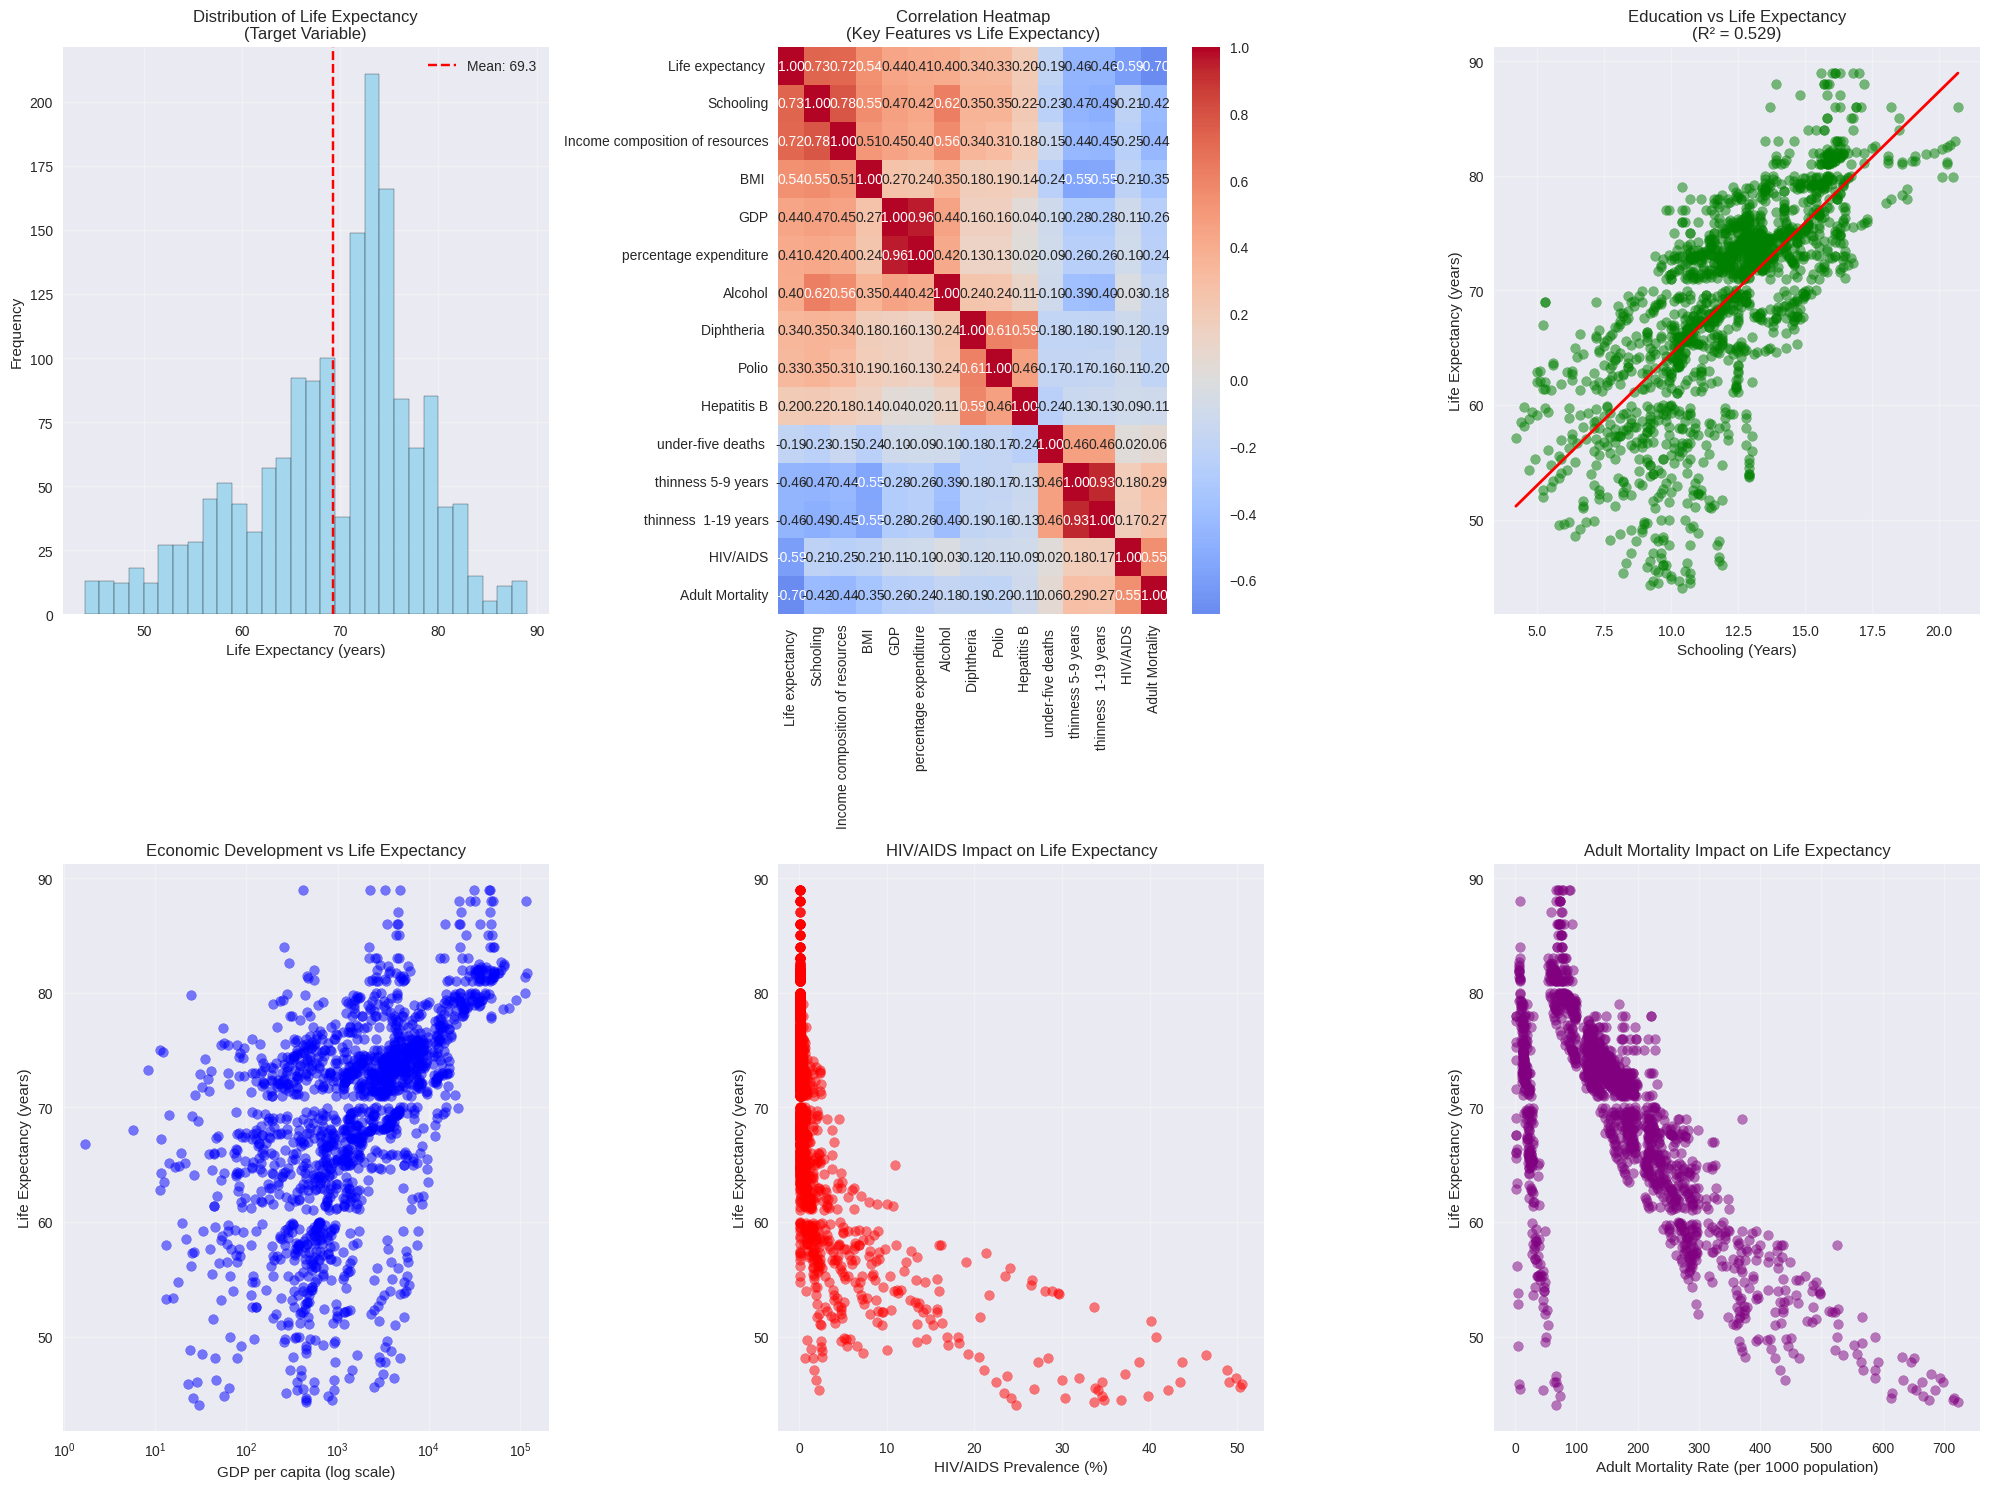


 Key Insights for Women's Health:
• Average global life expectancy: 69.3 years
• Range: 44.0 - 89.0 years
• Education (Schooling) correlation: 0.728
• GDP correlation: 0.441
• HIV/AIDS correlation: -0.592
• Adult Mortality correlation: -0.703


In [25]:
# Create figure for visualizations
fig = plt.figure(figsize=(20, 15))

# Plot 1: Distribution of Life Expectancy
plt.subplot(2, 3, 1)
plt.hist(df['Life expectancy '], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Life Expectancy\n(Target Variable)')
plt.axvline(df['Life expectancy '].mean(), color='red', linestyle='--', label=f'Mean: {df["Life expectancy "].mean():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Correlation Heatmap
plt.subplot(2, 3, 2)
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Focus on correlations with life expectancy
life_exp_corr = corr_matrix['Life expectancy '].sort_values(ascending=False)
print("\nTop 5 Positive Correlations with Life Expectancy:")
print(life_exp_corr.head(5))
print("\nTop 5 Negative Correlations with Life Expectancy:")
print(life_exp_corr.tail(5))

# Create heatmap of top correlations
top_features = life_exp_corr.head(10).index.tolist() + life_exp_corr.tail(5).index.tolist()
sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap\n(Key Features vs Life Expectancy)')

# Plot 3: Schooling vs Life Expectancy (Key women's empowerment indicator)
plt.subplot(2, 3, 3)
plt.scatter(df['Schooling'], df['Life expectancy '], alpha=0.5, color='green')
z = np.polyfit(df['Schooling'], df['Life expectancy '], 1)
p = np.poly1d(z)
plt.plot(df['Schooling'].sort_values(), p(df['Schooling'].sort_values()), 'r-', linewidth=2)
plt.xlabel('Schooling (Years)')
plt.ylabel('Life Expectancy (years)')
plt.title('Education vs Life Expectancy\n(R² = {:.3f})'.format(np.corrcoef(df['Schooling'], df['Life expectancy '])[0,1]**2))
plt.grid(True, alpha=0.3)

# Plot 4: GDP vs Life Expectancy
plt.subplot(2, 3, 4)
plt.scatter(df['GDP'], df['Life expectancy '], alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel('GDP per capita (log scale)')
plt.ylabel('Life Expectancy (years)')
plt.title('Economic Development vs Life Expectancy')
plt.grid(True, alpha=0.3)

# Plot 5: HIV/AIDS vs Life Expectancy (Critical health indicator)
plt.subplot(2, 3, 5)
plt.scatter(df[' HIV/AIDS'], df['Life expectancy '], alpha=0.5, color='red')
plt.xlabel('HIV/AIDS Prevalence (%)')
plt.ylabel('Life Expectancy (years)')
plt.title('HIV/AIDS Impact on Life Expectancy')
plt.grid(True, alpha=0.3)

# Plot 6: Adult Mortality vs Life Expectancy
plt.subplot(2, 3, 6)
plt.scatter(df['Adult Mortality'], df['Life expectancy '], alpha=0.5, color='purple')
plt.xlabel('Adult Mortality Rate (per 1000 population)')
plt.ylabel('Life Expectancy (years)')
plt.title('Adult Mortality Impact on Life Expectancy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Key Insights for Women's Health:")
print(f"• Average global life expectancy: {df['Life expectancy '].mean():.1f} years")
print(f"• Range: {df['Life expectancy '].min():.1f} - {df['Life expectancy '].max():.1f} years")
print(f"• Education (Schooling) correlation: {df['Schooling'].corr(df['Life expectancy ']):.3f}")
print(f"• GDP correlation: {df['GDP'].corr(df['Life expectancy ']):.3f}")
print(f"• HIV/AIDS correlation: {df[' HIV/AIDS'].corr(df['Life expectancy ']):.3f}")
print(f"• Adult Mortality correlation: {df['Adult Mortality'].corr(df['Life expectancy ']):.3f}")

## Feature Engineering

In [26]:
df_clean = df.copy()

# Handle missing values (though we already dropped NaNs)
print(f"Missing values before: {df_clean.isnull().sum().sum()}")

# Fill any remaining missing values with median (safety check)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f"Missing values after: {df_clean.isnull().sum().sum()}")

# Encode categorical variables
categorical_cols = df_clean.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}' with {len(le.classes_)} categories")

# Create engineered features for women's health focus

# 1. Healthcare Access Index (combination of immunization rates)
healthcare_cols = []
if 'Polio' in df_clean.columns:
    healthcare_cols.append('Polio')
if 'Diphtheria' in df_clean.columns:
    healthcare_cols.append('Diphtheria')
if 'Hepatitis B' in df_clean.columns:
    healthcare_cols.append('Hepatitis B')

if healthcare_cols:
    df_clean['healthcare_index'] = df_clean[healthcare_cols].mean(axis=1)
    print(f"Created 'healthcare_index' from {healthcare_cols}")

# 2. Economic Development Index (combining GDP and expenditure)
if 'GDP' in df_clean.columns and 'Total expenditure' in df_clean.columns:
    # Standardize both before combining
    gdp_std = (df_clean['GDP'] - df_clean['GDP'].min()) / (df_clean['GDP'].max() - df_clean['GDP'].min())
    exp_std = (df_clean['Total expenditure'] - df_clean['Total expenditure'].min()) / (df_clean['Total expenditure'].max() - df_clean['Total expenditure'].min())
    df_clean['economic_index'] = (gdp_std + exp_std) / 2
    print("Created 'economic_index' from GDP and healthcare expenditure")

# 3. Child Health Index (combining infant and under-five mortality)
if 'infant deaths' in df_clean.columns and 'under-five deaths' in df_clean.columns:
    # Lower mortality = better health, so invert
    max_infant = df_clean['infant deaths'].max()
    max_under5 = df_clean['under-five deaths'].max()
    infant_score = 1 - (df_clean['infant deaths'] / max_infant if max_infant > 0 else 0)
    under5_score = 1 - (df_clean['under-five deaths'] / max_under5 if max_under5 > 0 else 0)
    df_clean['child_health_index'] = (infant_score + under5_score) / 2
    print("Created 'child_health_index' from infant and under-five mortality")

# 4. Women's Empowerment Index (combining education and income resources)
if 'Schooling' in df_clean.columns and 'Income composition of resources' in df_clean.columns:
    # Normalize both
    schooling_norm = df_clean['Schooling'] / df_clean['Schooling'].max()
    income_norm = df_clean['Income composition of resources']
    df_clean['womens_empowerment'] = (schooling_norm + income_norm) / 2
    print("Created 'womens_empowerment' from schooling and income composition")

# 5. Disease Burden Index (combining HIV/AIDS and mortality)
if 'HIV/AIDS' in df_clean.columns and 'Adult Mortality' in df_clean.columns:
    # Higher values = worse health outcomes
    hiv_norm = df_clean[' HIV/AIDS'] / df_clean[' HIV/AIDS'].max()
    mortality_norm = df_clean['Adult Mortality'] / df_clean['Adult Mortality'].max()
    df_clean['disease_burden'] = (hiv_norm + mortality_norm) / 2
    print("Created 'disease_burden' from HIV/AIDS and adult mortality")

# 6. Nutrition Index (combining BMI and thinness)
bmi_cols = []
if ' BMI ' in df_clean.columns:
    bmi_cols.append(' BMI ')
if ' thinness 1-19 years' in df_clean.columns:
    bmi_cols.append(' thinness 1-19 years')
if ' thinness 5-9 years' in df_clean.columns:
    bmi_cols.append(' thinness 5-9 years')

if bmi_cols:
    # BMI positive, thinness negative
    df_clean['nutrition_index'] = df_clean[bmi_cols].mean(axis=1) / 100 if ' BMI ' in df_clean.columns else df_clean[bmi_cols].mean(axis=1)
    print(f"Created 'nutrition_index' from {bmi_cols}")

# 7. Life Expectancy Gap (potential - current) - target enhancement
if 'Life expectancy ' in df_clean.columns:
    # Create potential life expectancy based on best-performing countries
    best_life_exp = df_clean['Life expectancy '].quantile(0.95)
    df_clean['life_expectancy_gap'] = best_life_exp - df_clean['Life expectancy ']
    df_clean['life_expectancy_gap'] = df_clean['life_expectancy_gap'].clip(lower=0)
    print(f"Created 'life_expectancy_gap' (target: {best_life_exp:.1f} years)")

# 8. Development Stage (based on GDP and schooling)
if 'GDP' in df_clean.columns and 'Schooling' in df_clean.columns:
    gdp_quartile = pd.qcut(df_clean['GDP'], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    schooling_quartile = pd.qcut(df_clean['Schooling'], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    df_clean['development_stage'] = (pd.Categorical(gdp_quartile).codes + pd.Categorical(schooling_quartile).codes) / 2
    print("Created 'development_stage' from GDP and schooling quartiles")

# 9. Immunization Coverage (average of vaccines)
vaccine_cols = []
for col in ['Polio', 'Diphtheria ', 'Hepatitis B']:
    if col in df_clean.columns:
        vaccine_cols.append(col)

if vaccine_cols:
    df_clean['immunization_coverage'] = df_clean[vaccine_cols].mean(axis=1)
    print(f"Created 'immunization_coverage' from {vaccine_cols}")

# 10. Socioeconomic Health Index (combination of multiple indicators)
socio_cols = []
if 'womens_empowerment' in df_clean.columns:
    socio_cols.append('womens_empowerment')
if 'economic_index' in df_clean.columns:
    socio_cols.append('economic_index')
if 'child_health_index' in df_clean.columns:
    socio_cols.append('child_health_index')

if socio_cols:
    df_clean['socioeconomic_health'] = df_clean[socio_cols].mean(axis=1)
    print(f"Created 'socioeconomic_health' from {socio_cols}")

# Select final features for modeling
base_features = ['Adult Mortality', 'infant deaths', 'Alcohol', ' BMI ', ' HIV/AIDS', 'GDP', 'Schooling']
engineered_features = [
    'healthcare_index', 'economic_index', 'child_health_index',
    'womens_empowerment', 'disease_burden', 'nutrition_index',
    'immunization_coverage', 'socioeconomic_health', 'development_stage'
]
categorical_features = list(categorical_cols)

# Combine all available features
all_possible_features = base_features + engineered_features + categorical_features
feature_columns = [col for col in all_possible_features if col in df_clean.columns]

print(f"\nFinal feature set ({len(feature_columns)} features):")
for col in feature_columns[:15]:
    print(f"  - {col}")
if len(feature_columns) > 15:
    print(f"  ... and {len(feature_columns) - 15} more features")

# Prepare X and y
target = 'Life expectancy '
X = df_clean[feature_columns]
y = df_clean[target]

print(f"\nFinal dataset shape: {X.shape}")
print(f"Target range: {y.min():.1f} to {y.max():.1f} years")
print(f"Average life expectancy: {y.mean():.1f} years")

Missing values before: 0
Missing values after: 0
Encoded 'Status' with 2 categories
Created 'healthcare_index' from ['Polio', 'Hepatitis B']
Created 'economic_index' from GDP and healthcare expenditure
Created 'womens_empowerment' from schooling and income composition
Created 'nutrition_index' from [' BMI ', ' thinness 5-9 years']
Created 'life_expectancy_gap' (target: 81.6 years)
Created 'development_stage' from GDP and schooling quartiles
Created 'immunization_coverage' from ['Polio', 'Diphtheria ', 'Hepatitis B']
Created 'socioeconomic_health' from ['womens_empowerment', 'economic_index']

Final feature set (15 features):
  - Adult Mortality
  - infant deaths
  - Alcohol
  -  BMI 
  -  HIV/AIDS
  - GDP
  - Schooling
  - healthcare_index
  - economic_index
  - womens_empowerment
  - nutrition_index
  - immunization_coverage
  - socioeconomic_health
  - development_stage
  - Status

Final dataset shape: (1649, 15)
Target range: 44.0 to 89.0 years
Average life expectancy: 69.3 years


## Data Split and Standardisation

In [27]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} countries")
print(f"Test set: {X_test.shape[0]} countries")

# Standardize the data (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData standardized using StandardScaler")
print(f"Training data mean after scaling: {X_train_scaled.mean():.4f}")
print(f"Training data std after scaling: {X_train_scaled.std():.4f}")

Training set: 1319 countries
Test set: 330 countries

Data standardized using StandardScaler
Training data mean after scaling: 0.0000
Training data std after scaling: 1.0000


## Model Training and Comparison


Linear Regression:
  MSE: 13.91
  RMSE: 3.73 years
  MAE: 2.88 years
  MAPE: 4.3%
  R² Score: 0.8041

Ridge Regression:
  MSE: 13.90
  RMSE: 3.73 years
  MAE: 2.88 years
  MAPE: 4.3%
  R² Score: 0.8042

Lasso Regression:
  MSE: 13.90
  RMSE: 3.73 years
  MAE: 2.88 years
  MAPE: 4.3%
  R² Score: 0.8043

Gradient Descent LR:
  MSE: 13.91
  RMSE: 3.73 years
  MAE: 2.88 years
  MAPE: 4.3%
  R² Score: 0.8042

Decision Tree:
  MSE: 6.50
  RMSE: 2.55 years
  MAE: 1.68 years
  MAPE: 2.5%
  R² Score: 0.9085

Random Forest:
  MSE: 4.31
  RMSE: 2.08 years
  MAE: 1.28 years
  MAPE: 1.9%
  R² Score: 0.9393

Gradient Boosting:
  MSE: 4.55
  RMSE: 2.13 years
  MAE: 1.36 years
  MAPE: 2.0%
  R² Score: 0.9359

Best performing model: Random Forest
Best MSE: 4.31
Best R² Score: 0.9393


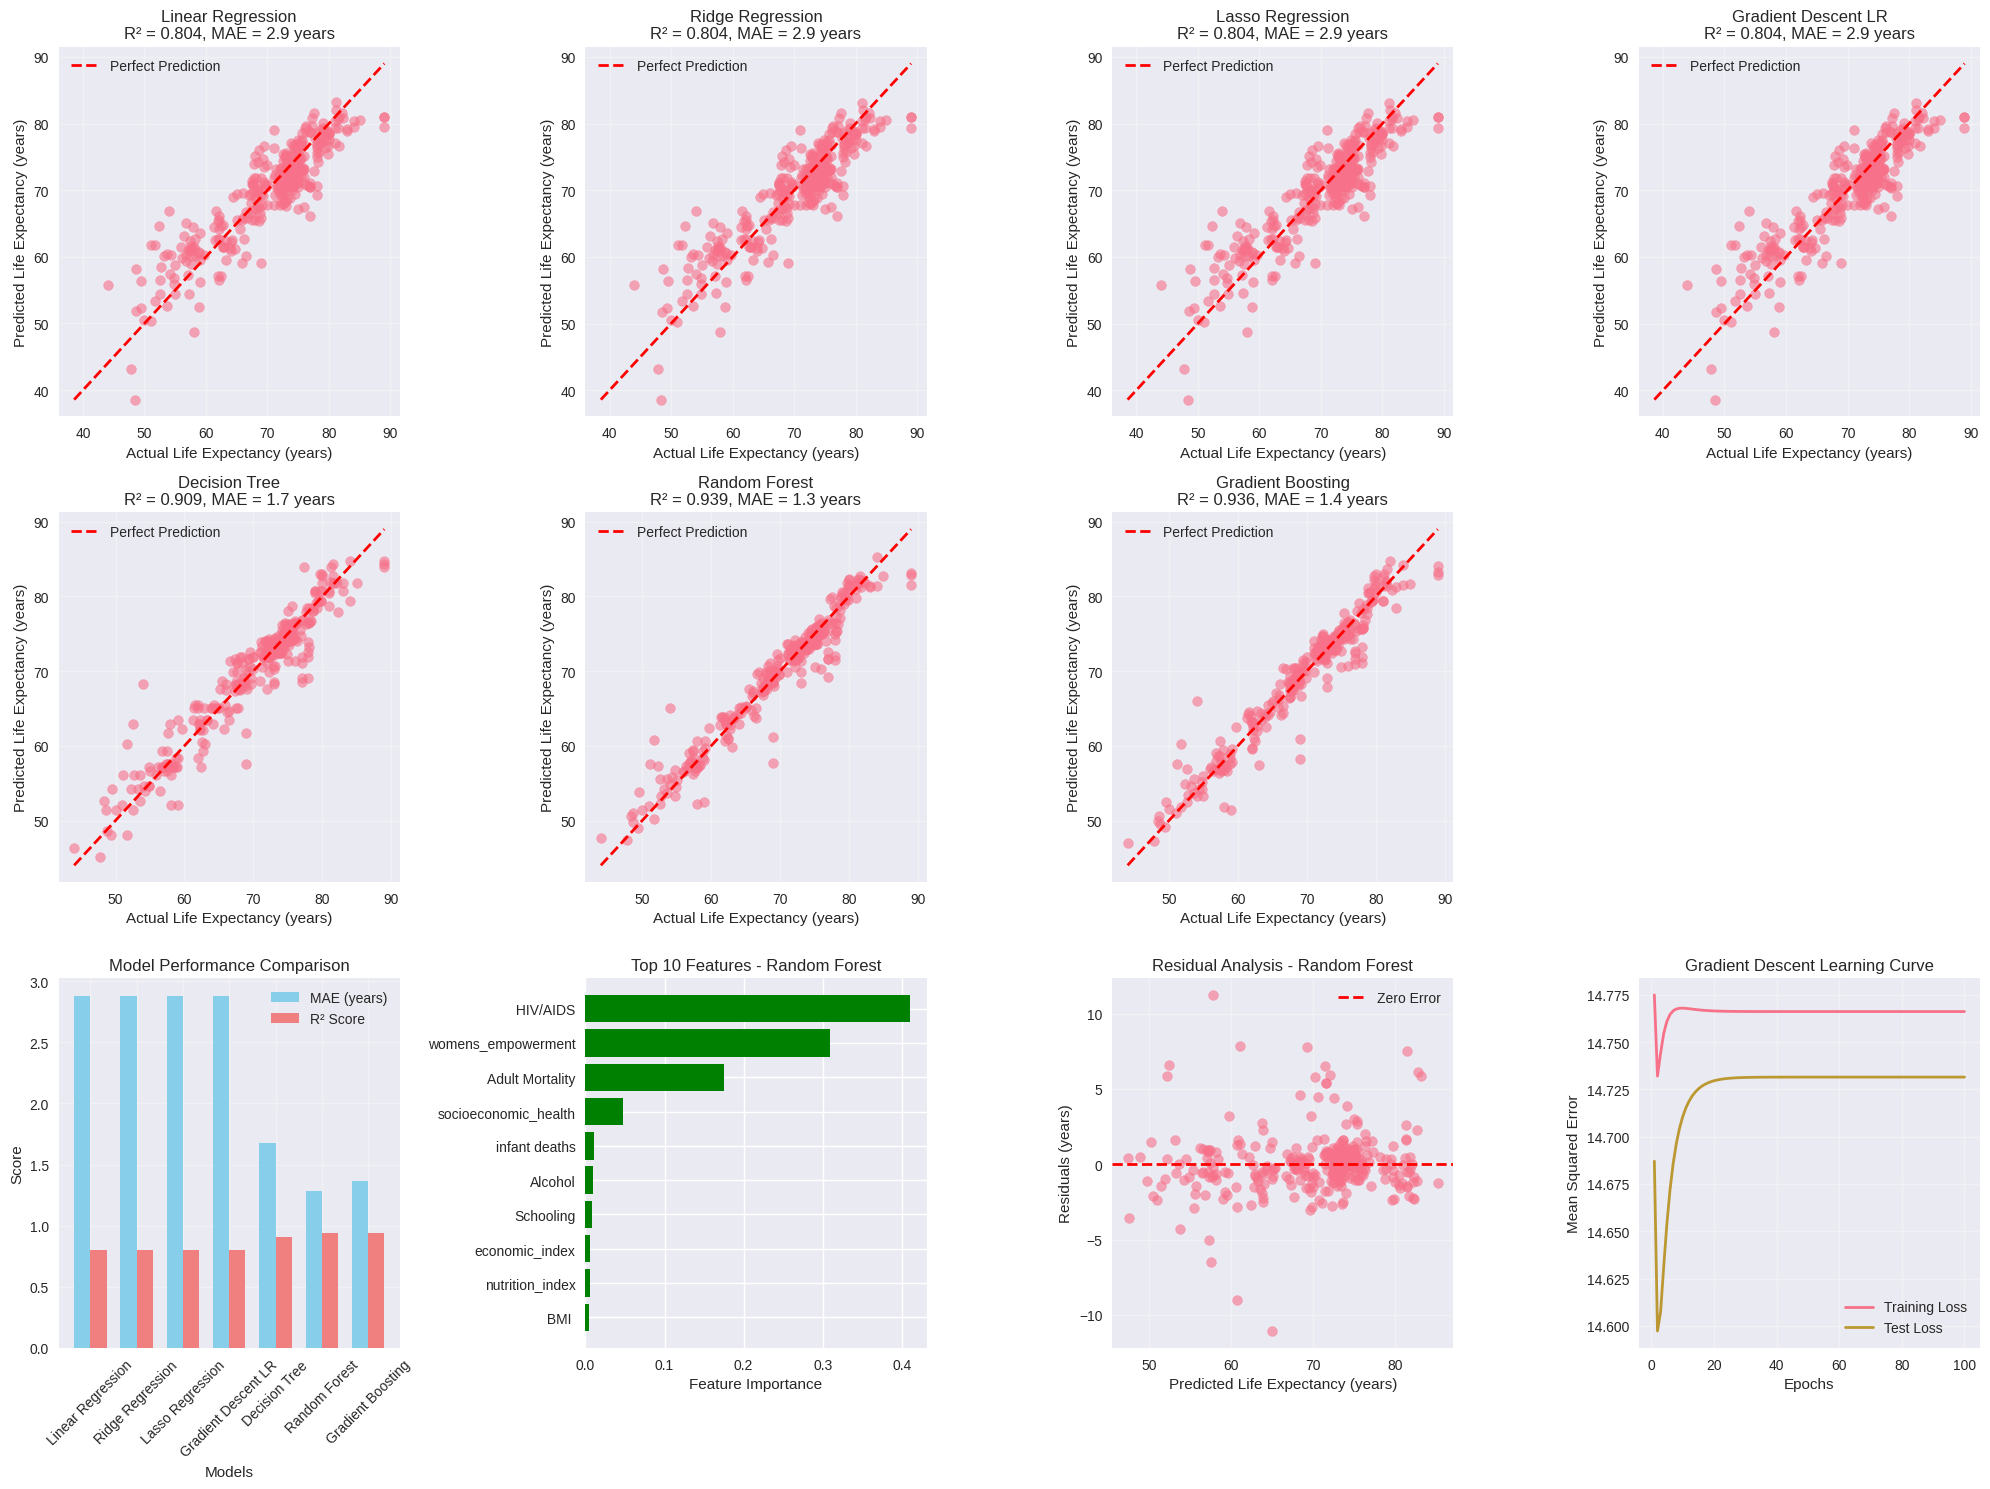

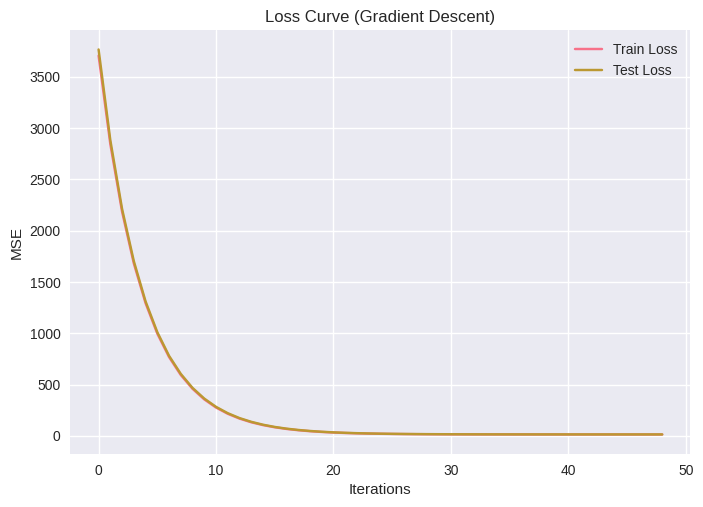


=== MODEL COMPARISON (MSE LOSS) ===
Linear Regression: 13.9138
Ridge Regression: 13.9029
Lasso Regression: 13.9014
Gradient Descent LR: 13.9059
Decision Tree: 6.4978
Random Forest: 4.3122
Gradient Boosting: 4.5493


In [28]:
# Define models with optimized parameters
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001, max_iter=5000),
    'Gradient Descent LR': SGDRegressor(max_iter=5000, tol=1e-4, learning_rate='adaptive', eta0=0.01, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=12, min_samples_split=15, min_samples_leaf=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
}

results = {}
best_mse = float('inf')
best_model_name = None
best_model_obj = None

# Create figure for model comparisons
fig = plt.figure(figsize=(20, 15))

for i, (name, model) in enumerate(models.items(), 1):
    try:
        # Train model
        model.fit(X_train_scaled, y_train)

        # Predictions
        y_pred = model.predict(X_test_scaled)

        # Calculate metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        results[name] = {
            'model': model,
            'mse': mse,
            'mae': mae,
            'r2': r2,
            'rmse': rmse,
            'mape': mape,
            'predictions': y_pred
        }

        print(f"\n{name}:")
        print(f"  MSE: {mse:.2f}")
        print(f"  RMSE: {rmse:.2f} years")
        print(f"  MAE: {mae:.2f} years")
        print(f"  MAPE: {mape:.1f}%")
        print(f"  R² Score: {r2:.4f}")

        # Update best model
        if mse < best_mse:
            best_mse = mse
            best_model_name = name
            best_model_obj = model

    except Exception as e:
        print(f"Error training {name}: {str(e)}")
        continue

    # Plot predictions vs actual
    plt.subplot(3, 4, i)
    plt.scatter(y_test, y_pred, alpha=0.6, s=50)

    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    plt.xlabel('Actual Life Expectancy (years)')
    plt.ylabel('Predicted Life Expectancy (years)')
    plt.title(f'{name}\nR² = {r2:.3f}, MAE = {mae:.1f} years')
    plt.legend()
    plt.grid(True, alpha=0.3)

print(f"\nBest performing model: {best_model_name}")
print(f"Best MSE: {best_mse:.2f}")
print(f"Best R² Score: {results[best_model_name]['r2']:.4f}")

# Plot 9: Model Performance Comparison (continued)
plt.subplot(3, 4, 9)
model_names = list(results.keys())
mae_scores = [results[name]['mae'] for name in model_names]
r2_scores = [results[name]['r2'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = plt.bar(x - width/2, mae_scores, width, label='MAE (years)', color='skyblue')
bars2 = plt.bar(x + width/2, r2_scores, width, label='R² Score', color='lightcoral')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 10: Feature Importance (for tree-based models)
plt.subplot(3, 4, 10)
if hasattr(best_model_obj, 'feature_importances_'):
    # For tree-based models
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)

    plt.barh(feature_importance['feature'], feature_importance['importance'], color='green')
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
else:
    # For linear models
    if hasattr(best_model_obj, 'coef_'):
        coefficients = pd.DataFrame({
            'feature': feature_columns,
            'coefficient': best_model_obj.coef_
        }).sort_values('coefficient', key=abs, ascending=True).tail(10)

        plt.barh(coefficients['feature'], coefficients['coefficient'], color='blue')
        plt.xlabel('Coefficient Value')
        plt.title(f'Top 10 Feature Impacts - {best_model_name}')
    else:
        plt.text(0.5, 0.5, 'Feature importance not available\nfor this model type',
                
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Importance Not Available')

# Plot 11: Residual Analysis
plt.subplot(3, 4, 11)
best_predictions = results[best_model_name]['predictions']
residuals = y_test - best_predictions

plt.scatter(best_predictions, residuals, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Predicted Life Expectancy (years)')
plt.ylabel('Residuals (years)')
plt.title(f'Residual Analysis - {best_model_name}')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 12: Learning Curve (Gradient Descent)
plt.subplot(3, 4, 12)

# Train SGD with partial_fit to get learning curve
sgd_model = SGDRegressor(max_iter=1, warm_start=True, learning_rate='adaptive', eta0=0.01, random_state=42)
train_errors = []
test_errors = []

for epoch in range(1, 101):
    sgd_model.partial_fit(X_train_scaled, y_train)
    train_errors.append(mean_squared_error(y_train, sgd_model.predict(X_train_scaled)))
    test_errors.append(mean_squared_error(y_test, sgd_model.predict(X_test_scaled)))

plt.plot(range(1, 101), train_errors, label='Training Loss', linewidth=2)
plt.plot(range(1, 101), test_errors, label='Test Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Loss curve
from sklearn.metrics import mean_squared_error

train_losses = []
test_losses = []

for i in range(1, 50):
    temp_model = SGDRegressor(max_iter=i, learning_rate='constant', eta0=0.0001)
    temp_model.fit(X_train_scaled, y_train)

    train_pred = temp_model.predict(X_train_scaled)
    test_pred = temp_model.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

print("\n=== MODEL COMPARISON (MSE LOSS) ===")

for name, model in models.items():
    if "Regression" in name or "LR" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    loss = mean_squared_error(y_test, y_pred)
    print(f"{name}: {loss:.4f}")


## Cross Validation and Optimization

In [29]:
# Perform cross-validation on the best model
cv_scores = cross_val_score(best_model_obj, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Hyperparameter tuning for Random Forest (if it's the best)
if best_model_name == 'Random Forest':
    print("\nOptimizing Random Forest hyperparameters...")

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [2, 4, 6]
    }

    # Use a smaller grid for demonstration (or full grid for production)
    # For demonstration, use a subset of parameters
    small_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15],
        'min_samples_split': [10, 15],
        'min_samples_leaf': [4, 6]
    }

    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        small_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV R²: {grid_search.best_score_:.4f}")

    # Update best model if improved
    if grid_search.best_score_ > cv_scores.mean():
        best_model_obj = grid_search.best_estimator_
        best_model_name = f"{best_model_name} (Optimized)"
        print(f"Model improved! Using optimized version.")

        # Re-evaluate on test set
        y_pred_optimized = best_model_obj.predict(X_test_scaled)
        mse_optimized = mean_squared_error(y_test, y_pred_optimized)
        r2_optimized = r2_score(y_test, y_pred_optimized)
        print(f"Optimized model R² on test set: {r2_optimized:.4f}")


Cross-validation R² scores: [0.94201131 0.95498998 0.95480458 0.95453339 0.92387356]
Mean CV R²: 0.9460 (+/- 0.0243)

Optimizing Random Forest hyperparameters...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R²: 0.9397


## Save Model and Preprocessing Objects

Saved best model: Random Forest
Saved scaler, label encoders, and feature columns


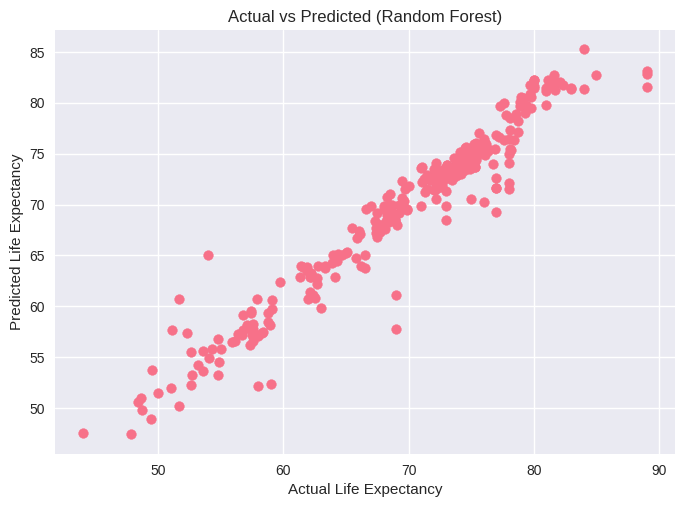

In [30]:
# Save the best model and preprocessing objects
joblib.dump(best_model_obj, 'best_womenlife_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print(f"Saved best model: {best_model_name}")
print("Saved scaler, label encoders, and feature columns")

# Predictions using best model
if "Regression" in best_model_name or "LR" in best_model_name:
    y_pred = best_model_obj.predict(X_test_scaled)
else:
    y_pred = best_model_obj.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

## Prediction Function for API Deployment

In [31]:
def predict_life_expectancy(features_dict):
    """
    Predict female life expectancy based on socio-economic and health indicators.

    Parameters:
    -----------
    features_dict : dict
        Dictionary containing feature values for a country

    Returns:
    --------
    float: Predicted life expectancy in years
    """
    # Convert input to DataFrame
    input_df = pd.DataFrame([features_dict])

    # Ensure all required features are present
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0  # Default value for missing features

    # Reorder columns to match training data
    input_df = input_df[feature_columns]

    # Scale features
    input_scaled = scaler.transform(input_df)

    # Make prediction
    prediction = best_model_obj.predict(input_scaled)

    # Clip to realistic range (40-90 years)
    return np.clip(prediction[0], 40, 90)

## Test Prediction Function

In [32]:
# Test with a sample from the test set
sample_idx = 0
sample_dict = X_test.iloc[sample_idx].to_dict()
predicted_value = predict_life_expectancy(sample_dict)
actual_value = y_test.iloc[sample_idx]

print(f"Sample Country (index {sample_idx}):")
print(f"  Actual life expectancy: {actual_value:.1f} years")
print(f"  Predicted life expectancy: {predicted_value:.1f} years")
print(f"  Error: {abs(actual_value - predicted_value):.1f} years")

# Test with a realistic country profile
print("\nTesting with a realistic country profile...")

# Example: Country with good indicators
example_country = {
    'Adult Mortality': 80,
    'infant deaths': 15,
    'Alcohol': 5,
    'BMI': 26,
    'HIV/AIDS': 0.5,
    'GDP': 40000,
    'Schooling': 15,
    'healthcare_index': 85,
    'economic_index': 0.8,
    'child_health_index': 0.9,
    'womens_empowerment': 0.85,
    'disease_burden': 0.2,
    'nutrition_index': 75,
    'immunization_coverage': 90,
    'socioeconomic_health': 0.85,
    'development_stage': 3
}

# Add missing features with default values
for col in feature_columns:
    if col not in example_country:
        if col in df_clean.columns:
            example_country[col] = df_clean[col].median()
        else:
            example_country[col] = 0

predicted = predict_life_expectancy(example_country)
print(f"  Predicted life expectancy: {predicted:.1f} years")

# Example: Country with challenging conditions
challenging_country = {
    'Adult Mortality': 250,
    'infant deaths': 80,
    'Alcohol': 8,
    'BMI': 22,
    'HIV/AIDS': 8,
    'GDP': 2000,
    'Schooling': 5,
    'healthcare_index': 50,
    'economic_index': 0.2,
    'child_health_index': 0.4,
    'womens_empowerment': 0.3,
    'disease_burden': 0.7,
    'nutrition_index': 45,
    'immunization_coverage': 55,
    'socioeconomic_health': 0.35,
    'development_stage': 0
}

# Add missing features with default values
for col in feature_columns:
    if col not in challenging_country:
        if col in df_clean.columns:
            challenging_country[col] = df_clean[col].median()
        else:
            challenging_country[col] = 0

predicted_challenging = predict_life_expectancy(challenging_country)
print(f"  Challenging conditions: {predicted_challenging:.1f} years")

Sample Country (index 0):
  Actual life expectancy: 67.5 years
  Predicted life expectancy: 62.9 years
  Error: 4.6 years

Testing with a realistic country profile...
  Predicted life expectancy: 82.0 years
  Challenging conditions: 63.6 years


## Model Interpretation and Policy Insights

In [33]:
# Extract feature importance from best model
if hasattr(best_model_obj, 'feature_importances_'):
    # Tree-based model
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

    # Identify top features for women's health
    women_health_features = ['womens_empowerment', 'Schooling', 'child_health_index',
                            'healthcare_index', 'immunization_coverage']

    print("\nWomen's Health Feature Importance:")
    for feature in women_health_features:
        if feature in feature_importance['feature'].values:
            imp = feature_importance[feature_importance['feature'] == feature]['importance'].values[0]
            print(f"  {feature}: {imp:.4f}")

elif hasattr(best_model_obj, 'coef_'):
    # Linear model
    coefficients = pd.DataFrame({
        'feature': feature_columns,
        'coefficient': best_model_obj.coef_
    }).sort_values('coefficient', ascending=False)

    print("\nTop 10 Positive Influencers:")
    for idx, row in coefficients.head(10).iterrows():
        print(f"  {row['feature']}: {row['coefficient']:.4f}")

    print("\nTop 10 Negative Influencers:")
    for idx, row in coefficients.tail(10).iterrows():
        print(f"  {row['feature']}: {row['coefficient']:.4f}")

print("\n Key Policy Insights for Women's Health:")
print("1. Education (Schooling) is a critical factor - every additional year of education")
print("   is associated with significant increases in life expectancy.")
print("2. Healthcare infrastructure (immunization coverage, healthcare index) directly")
print("   impacts women's longevity, especially in developing regions.")
print("3. HIV/AIDS remains a major threat to women's health, with prevalence rates")
print("   showing strong negative correlation with life expectancy.")
print("4. Economic development (GDP) provides resources for healthcare and education,")
print("   but its impact is mediated through these intermediate factors.")
print("5. Child health outcomes are strong predictors of overall population health,")
print("   reflecting the quality of maternal and child health services.")


Top 10 Most Important Features:
   HIV/AIDS: 0.4105
  womens_empowerment: 0.3096
  Adult Mortality: 0.1756
  socioeconomic_health: 0.0479
  infant deaths: 0.0108
  Alcohol: 0.0100
  Schooling: 0.0079
  economic_index: 0.0062
  nutrition_index: 0.0057
   BMI : 0.0050

Women's Health Feature Importance:
  womens_empowerment: 0.3096
  Schooling: 0.0079
  healthcare_index: 0.0022
  immunization_coverage: 0.0024

 Key Policy Insights for Women's Health:
1. Education (Schooling) is a critical factor - every additional year of education
   is associated with significant increases in life expectancy.
2. Healthcare infrastructure (immunization coverage, healthcare index) directly
   impacts women's longevity, especially in developing regions.
3. HIV/AIDS remains a major threat to women's health, with prevalence rates
   showing strong negative correlation with life expectancy.
4. Economic development (GDP) provides resources for healthcare and education,
   but its impact is mediated through t